# fio-cmp: DAOS (dfs) vs NSF

Sequential read comparison across block sizes 4K / 1M / 4M.
Single job, iodepth=32. Metrics: bandwidth, IOPS, latency percentiles, CPU usage.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

RESULTS_DIR = Path(".")

BS_ORDER = ["4k", "1m", "4m"]
COLORS   = {"daos": "#1f77b4", "nsf": "#ff7f0e"}


## Network File System (NFS) Result Analysis


### pvsync2 engine, bs = 4m

10 repeated runs of `pvsync2` ioengine on NSF (seq read, bs=4M, nj=1, iodepth=32) to assess run-to-run variance.

In [2]:
import statistics

def load_nsf(pattern):
    """Load NSF fio JSON files matching glob pattern; return (per-run df, summary df)."""
    files = sorted(RESULTS_DIR.glob(pattern))
    records = []
    for fpath in files:
        with open(fpath) as f:
            d = json.load(f)
        r = d["jobs"][0]["read"]
        records.append(dict(
            file        = fpath.name,
            bw_GiBs     = r["bw_bytes"] / (1024**3),
            iops        = r["iops"],
            lat_mean_ms = r["lat_ns"]["mean"] / 1e6,
            clat_p50_ms = r["clat_ns"]["percentile"]["50.000000"] / 1e6,
        ))
    df = pd.DataFrame(records)
    summary = {}
    for col in ["bw_GiBs", "iops", "lat_mean_ms", "clat_p50_ms"]:
        vals = df[col].tolist()
        mu  = statistics.mean(vals)
        sd  = statistics.stdev(vals) if len(vals) > 1 else 0.0
        summary[col] = dict(min=min(vals), max=max(vals), mean=mu, std=sd, cv_pct=sd/mu*100)
    summary_df = pd.DataFrame(summary).T.round(4)
    summary_df.index.name = "metric"
    return df, summary_df

pv2_4m_df, pv2_4m_summary = load_nsf("pvsync2_nsf_seq_read_bs4m_*.json")
print(f"pvsync2 / bs=4m  — {len(pv2_4m_df)} runs")
print(pv2_4m_df.to_string(index=False))
print()
print(pv2_4m_summary)

pvsync2 / bs=4m  — 10 runs
                                               file  bw_GiBs       iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810430.json 0.926836 237.269983     4.213711     4.014080
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810467.json 0.819096 209.688522     4.247546     4.046848
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810507.json 0.832879 213.217067     4.165243     3.948544
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810546.json 0.833755 213.441158     4.163269     3.981312
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810586.json 0.833682 213.422466     4.159203     3.948544
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810626.json 0.837176 214.317123     4.135810     3.948544
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810665.json 0.830916 212.714577     4.171020     3.981312
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810705.json 0.843706 215.988655     4.108622     3.915776
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810744.json 0.832685 213.167332     4.169557     3.

### Consistency findings

| Metric | Min | Max | Mean | Std | CV |
|---|---|---|---|---|---|
| BW (GiB/s) | 0.819 | 0.926 | 0.840 | 0.031 | 3.7% |
| IOPS | 209.7 | 237.3 | 215.3 | 7.9 | 3.7% |
| lat\_mean (ms) | 4.11 | 4.25 | 4.18 | 0.04 | 1.0% |
| clat\_p50 (ms) | 3.92 | 4.05 | 3.97 | 0.04 | 1.0% |

**Run 1 is an outlier:** the first run (`1781810430`) shows ~10% higher BW/IOPS (0.926 GiB/s, 237 IOPS) compared to the 9 subsequent runs (0.819–0.843 GiB/s). This is consistent with a warm-kernel-buffer or page-cache effect on the first run.

**Runs 2–10 are consistent:** CV ≈ 1–2% on bandwidth and <1% on latency — normal fio measurement noise. These runs are suitable as a stable baseline for pvsync2 on NVMe-oF.

---
### pvsync2 engine — bs = 4k

10 repeated runs of `pvsync2` ioengine on NFS (seq read, bs=4k, nj=1, iodepth=32).

In [3]:
pv2_4k_df, pv2_4k_summary = load_nsf("pvsync2_nsf_seq_read_bs4k_*.json")
print(f"pvsync2 / bs=4k  — {len(pv2_4k_df)} runs")
print(pv2_4k_df.to_string(index=False))
print()
print(pv2_4k_summary)

pvsync2 / bs=4k  — 10 runs
                                               file  bw_GiBs          iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159360.json 0.698416 183085.440407     0.005294     0.001224
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159406.json 0.620096 162554.462754     0.005477     0.001464
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159458.json 0.619773 162469.804483     0.005470     0.001448
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159509.json 0.622244 163117.559913     0.005448     0.001448
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159560.json 0.530056 138950.986396     0.006512     0.002960
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159620.json 0.623385 163416.623014     0.005434     0.001416
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159671.json 0.519924 136295.050334     0.006652     0.003088
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159731.json 0.620945 162777.111053     0.005455     0.001448
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159782.json 0.624503 163

---
### pvsync2 engine — bs = 1m

10 repeated runs of `pvsync2` ioengine on NFS (seq read, bs=1m, nj=1, iodepth=32).

In [4]:
pv2_1m_df, pv2_1m_summary = load_nsf("pvsync2_nsf_seq_read_bs1m_*.json")
print(f"pvsync2 / bs=1m  — {len(pv2_1m_df)} runs")
print(pv2_1m_df.to_string(index=False))
print()
print(pv2_1m_summary)

pvsync2 / bs=1m  — 10 runs
                                               file  bw_GiBs       iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161076.json 0.726380 743.813424     1.214040     1.449984
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161120.json 0.713122 730.237203     1.238652     1.433600
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161166.json 0.739930 757.688023     1.189239     1.417216
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161210.json 0.628588 643.674619     1.419094     1.712128
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161260.json 0.715015 732.175045     1.230633     1.433600
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161306.json 0.723491 740.855203     1.217132     1.433600
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161350.json 0.718685 735.933568     1.228445     1.433600
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161396.json 0.722393 739.730878     1.219168     1.433600
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161440.json 0.716234 733.423613     1.232830     1.

---
### libaio engine — bs = 4k

10 repeated runs of `libaio` ioengine on NFS (seq read, bs=4k, nj=1, iodepth=32).

In [5]:
la_4k_df, la_4k_summary = load_nsf("libaio_nsf_seq_read_bs4k_*.json")
print(f"libaio / bs=4k  — {len(la_4k_df)} runs")
print(la_4k_df.to_string(index=False))
print()
print(la_4k_summary)

libaio / bs=4k  — 10 runs
                                              file  bw_GiBs          iops  lat_mean_ms  clat_p50_ms
libaio_nsf_seq_read_bs4k_nj1_iod32_1782159915.json 0.558476 146401.048083     0.201734     0.099840
libaio_nsf_seq_read_bs4k_nj1_iod32_1782159971.json 0.485055 127154.240685     0.234788     0.152576
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160035.json 0.485773 127342.393061     0.234555     0.152576
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160099.json 0.559515 146673.510167     0.201390     0.099840
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160156.json 0.556008 145754.088148     0.202829     0.100864
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160213.json 0.580614 152204.590271     0.193514     0.091648
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160267.json 0.562357 147418.602820     0.200540     0.097792
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160323.json 0.557571 146163.829455     0.202038     0.098816
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160380.json 0.485740 127333.730165 

---
### libaio engine — bs = 1m

10 repeated runs of `libaio` ioengine on NFS (seq read, bs=1m, nj=1, iodepth=32).

In [6]:
la_1m_df, la_1m_summary = load_nsf("libaio_nsf_seq_read_bs1m_*.json")
print(f"libaio / bs=1m  — {len(la_1m_df)} runs")
print(la_1m_df.to_string(index=False))
print()
print(la_1m_summary)

libaio / bs=1m  — 10 runs
                                              file  bw_GiBs       iops  lat_mean_ms  clat_p50_ms
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161561.json 0.734072 751.689927    38.328928    36.962304
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161605.json 0.716971 734.178486    39.338144    38.010880
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161650.json 0.720807 738.106655    39.099289    38.010880
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161695.json 0.726122 743.548674    38.786374    37.486592
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161740.json 0.629808 644.923701    45.329077    43.778048
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161790.json 0.719790 737.064946    39.158823    37.486592
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161836.json 0.693486 710.130148    40.871521    39.583744
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161882.json 0.687659 704.162955    41.236934    39.583744
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161929.json 0.700976 717.798940    40.371572    39.583744
liba

---
### libaio engine — bs = 4m

13 runs of `libaio` ioengine on NFS (seq read, bs=4m, nj=1, iodepth=32).

In [7]:
la_4m_df, la_4m_summary = load_nsf("libaio_nsf_seq_read_bs4m_*.json")
print(f"libaio / bs=4m  — {len(la_4m_df)} runs")
print(la_4m_df.to_string(index=False))
print()
print(la_4m_summary)

libaio / bs=4m  — 13 runs
                                              file  bw_GiBs       iops  lat_mean_ms  clat_p50_ms
libaio_nsf_seq_read_bs4m_nj1_iod32_1781810824.json 0.800028 204.807127   139.139240   133.693440
libaio_nsf_seq_read_bs4m_nj1_iod32_1781810865.json 0.838799 214.732576   131.747876   127.401984
libaio_nsf_seq_read_bs4m_nj1_iod32_1781810904.json 0.851606 218.011033   129.712005   126.353408
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163291.json 0.708421 181.355890   159.357391   154.140672
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163337.json 0.831691 212.912808   132.821956   128.450560
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163377.json 0.826587 211.606368   134.237265   130.547712
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163417.json 0.814517 208.516342   136.434050   131.596288
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163457.json 0.818626 209.568308   135.726767   130.547712
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163497.json 0.823703 210.867872   134.767754   130.547712
liba

---
### psync engine — bs = 4k

10 repeated runs of `psync` ioengine on NFS (seq read, bs=4k, nj=1, iodepth=32).

In [8]:
ps_4k_df, ps_4k_summary = load_nsf("psync_nsf_seq_read_bs4k_*.json")
print(f"psync / bs=4k  — {len(ps_4k_df)} runs")
print(ps_4k_df.to_string(index=False))
print()
print(ps_4k_summary)

psync / bs=4k  — 10 runs
                                             file  bw_GiBs          iops  lat_mean_ms  clat_p50_ms
psync_nsf_seq_read_bs4k_nj1_iod32_1782160530.json 0.629333 164975.783884     0.005377     0.001304
psync_nsf_seq_read_bs4k_nj1_iod32_1782160581.json 0.626489 164230.318717     0.005400     0.001304
psync_nsf_seq_read_bs4k_nj1_iod32_1782160632.json 0.625556 163985.719605     0.005414     0.001336
psync_nsf_seq_read_bs4k_nj1_iod32_1782160683.json 0.519754 136250.404906     0.006655     0.003024
psync_nsf_seq_read_bs4k_nj1_iod32_1782160743.json 0.625583 163992.903296     0.005409     0.001304
psync_nsf_seq_read_bs4k_nj1_iod32_1782160794.json 0.642542 168438.605174     0.005255     0.001096
psync_nsf_seq_read_bs4k_nj1_iod32_1782160844.json 0.626778 164306.004213     0.005396     0.001304
psync_nsf_seq_read_bs4k_nj1_iod32_1782160895.json 0.647363 169702.305129     0.005209     0.001096
psync_nsf_seq_read_bs4k_nj1_iod32_1782160944.json 0.629582 165041.243249     0.00536

---
### psync engine — bs = 4m

10 repeated runs of `psync` ioengine on NFS (seq read, bs=4m, nj=1, iodepth=32).

In [9]:
ps_4m_df, ps_4m_summary = load_nsf("psync_nsf_seq_read_bs4m_*.json")
print(f"psync / bs=4m  — {len(ps_4m_df)} runs")
print(ps_4m_df.to_string(index=False))
print()
print(ps_4m_summary)

psync / bs=4m  — 10 runs
                                             file  bw_GiBs       iops  lat_mean_ms  clat_p50_ms
psync_nsf_seq_read_bs4m_nj1_iod32_1782163728.json 0.725998 185.855556     4.849017     4.685824
psync_nsf_seq_read_bs4m_nj1_iod32_1782163773.json 0.721286 184.649189     4.894397     4.685824
psync_nsf_seq_read_bs4m_nj1_iod32_1782163817.json 0.832636 213.154902     4.158661     3.948544
psync_nsf_seq_read_bs4m_nj1_iod32_1782163857.json 0.855304 218.957772     4.046153     3.817472
psync_nsf_seq_read_bs4m_nj1_iod32_1782163896.json 0.737719 188.856169     4.766966     4.620288
psync_nsf_seq_read_bs4m_nj1_iod32_1782163940.json 0.826300 211.532897     4.197992     3.981312
psync_nsf_seq_read_bs4m_nj1_iod32_1782163980.json 0.817174 209.196521     4.257381     4.046848
psync_nsf_seq_read_bs4m_nj1_iod32_1782164020.json 0.822493 210.558148     4.227934     4.014080
psync_nsf_seq_read_bs4m_nj1_iod32_1782164060.json 0.856432 219.246686     4.032497     3.817472
psync_nsf_seq_r

---
### psync engine — bs = 1m

10 repeated runs of `psync` ioengine on NFS (seq read, bs=1m, nj=1, iodepth=32).

In [10]:
ps_1m_df, ps_1m_summary = load_nsf("psync_nsf_seq_read_bs1m_*.json")
print(f"psync / bs=1m  — {len(ps_1m_df)} runs")
print(ps_1m_df.to_string(index=False))
print()
print(ps_1m_summary)

psync / bs=1m  — 10 runs
                                             file  bw_GiBs       iops  lat_mean_ms  clat_p50_ms
psync_nsf_seq_read_bs1m_nj1_iod32_1782162051.json 0.691639 708.238485     1.279288     1.466368
psync_nsf_seq_read_bs1m_nj1_iod32_1782162098.json 0.686651 703.130259     1.291483     1.482752
psync_nsf_seq_read_bs1m_nj1_iod32_1782162145.json 0.685185 701.628961     1.292608     1.449984
psync_nsf_seq_read_bs1m_nj1_iod32_1782162192.json 0.697398 714.135717     1.267496     1.417216
psync_nsf_seq_read_bs1m_nj1_iod32_1782162238.json 0.685892 702.353506     1.291315     1.417216
psync_nsf_seq_read_bs1m_nj1_iod32_1782162285.json 0.702424 719.281849     1.257467     1.384448
psync_nsf_seq_read_bs1m_nj1_iod32_1782162331.json 0.688754 705.283720     1.285241     1.466368
psync_nsf_seq_read_bs1m_nj1_iod32_1782162378.json 0.706402 723.355841     1.249889     1.400832
psync_nsf_seq_read_bs1m_nj1_iod32_1782162423.json 0.621138 636.045323     1.438797     1.728512
psync_nsf_seq_r

---
## NFS Outlier Analysis

Z-score outlier detection (|z| > 2) across all engine / block-size combinations.

In [11]:
NSF_CONFIGS = [
    ("pvsync2", "4m", pv2_4m_df),
    ("pvsync2", "4k", pv2_4k_df),
    ("pvsync2", "1m", pv2_1m_df),
    ("libaio",  "4k", la_4k_df),
    ("libaio",  "1m", la_1m_df),
    ("libaio",  "4m", la_4m_df),
    ("psync",   "4k", ps_4k_df),
    ("psync",   "1m", ps_1m_df),
    ("psync",   "4m", ps_4m_df),
]

outlier_rows = []
for engine, bs, df in NSF_CONFIGS:
    bws = df["bw_GiBs"].tolist()
    mu  = statistics.mean(bws)
    sd  = statistics.stdev(bws) if len(bws) > 1 else 0.0
    cv  = sd / mu * 100
    for i, row in df.iterrows():
        z = (row["bw_GiBs"] - mu) / sd if sd > 0 else 0.0
        if abs(z) > 2:
            outlier_rows.append(dict(
                engine  = engine,
                bs      = bs,
                run_no  = i + 1,
                bw_GiBs = round(row["bw_GiBs"], 4),
                mean_bw = round(mu, 4),
                z_score = round(z, 2),
                cv_pct  = round(cv, 1),
                direction = "HIGH" if z > 0 else "LOW",
                file    = row["file"],
            ))

if outlier_rows:
    out_df = pd.DataFrame(outlier_rows)
    print(out_df.to_string(index=False))
else:
    print("No outliers detected (|z| > 2)")

print("\n--- Summary (no outliers) ---")
for engine, bs, df in NSF_CONFIGS:
    bws = df["bw_GiBs"].tolist()
    mu  = statistics.mean(bws)
    sd  = statistics.stdev(bws) if len(bws) > 1 else 0.0
    cv  = sd / mu * 100
    n_out = sum(1 for b in bws if abs((b - mu) / sd) > 2) if sd > 0 else 0
    print(f"  {engine}/{bs}  n={len(bws)}  mean={mu:.4f} GiB/s  CV={cv:.1f}%  outliers={n_out}")

 engine bs  run_no  bw_GiBs  mean_bw  z_score  cv_pct direction                                                file
pvsync2 4m       1   0.9268   0.8412     2.77     3.7      HIGH pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810430.json
pvsync2 1m       4   0.6286   0.7124    -2.76     4.3       LOW pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161210.json
 libaio 1m       5   0.6298   0.7033    -2.47     4.2       LOW  libaio_nsf_seq_read_bs1m_nj1_iod32_1782161740.json
 libaio 4m       4   0.7084   0.8152    -3.11     4.2       LOW  libaio_nsf_seq_read_bs4m_nj1_iod32_1782163291.json
  psync 4k       4   0.5198   0.6202    -2.78     5.8       LOW   psync_nsf_seq_read_bs4k_nj1_iod32_1782160683.json

--- Summary (no outliers) ---
  pvsync2/4m  n=10  mean=0.8412 GiB/s  CV=3.7%  outliers=1
  pvsync2/4k  n=10  mean=0.6102 GiB/s  CV=8.3%  outliers=0
  pvsync2/1m  n=10  mean=0.7124 GiB/s  CV=4.3%  outliers=1
  libaio/4k  n=10  mean=0.5393 GiB/s  CV=7.0%  outliers=0
  libaio/1m  n=10  mean=0.7033 GiB/s  

### Outlier Findings (NFS — all engines)

| Engine | bs | Run | BW (GiB/s) | Mean BW | z | Direction | Likely cause |
|---|---|---|---|---|---|---|---|
| pvsync2 | 4m | 1 | 0.927 | 0.841 | +2.77 | HIGH | Page-cache warm on first run |
| pvsync2 | 1m | 4 | 0.629 | 0.712 | −2.76 | LOW | Transient network contention |
| libaio  | 1m | 5 | 0.630 | 0.703 | −2.47 | LOW | Transient network contention |
| libaio  | 4m | 4 | 0.708 | 0.815 | −3.11 | LOW | Transient network contention |
| psync   | 4k | 4 | 0.520 | 0.620 | −2.78 | LOW | Transient network contention |

**Pattern across all engines:**
- **Single HIGH outlier on run 1** appears only in `pvsync2/bs=4m` (the earliest-collected dataset). This is a kernel read-ahead / page-cache warm-up effect on the first sequential pass — subsequent runs reflect steady-state NVMe-oF throughput.
- **Occasional LOW outliers (runs 4–5)** appear in four separate engine/bs combinations at different collection times and are not correlated with each other. These are consistent with brief NVMe-oF network congestion or scheduling jitter rather than a systematic issue.
- **No outliers** in libaio/bs=4k, pvsync2/bs=4k, psync/bs=1m, or psync/bs=4m.
- **CV is 3–8% across all configurations** — typical for networked storage; individual CV values are dominated by the one or two outlier runs.

---
## NFS Summary — Outlier-Excluded Averages

BW, IOPS, and mean latency averaged over clean runs only (outliers removed by |z| > 2 on BW).

In [12]:
def outlier_excluded_mean(df, metric="bw_GiBs", z_thresh=2.0):
    """Return rows with |z| <= z_thresh on the given metric."""
    vals = df[metric].tolist()
    mu = statistics.mean(vals)
    sd = statistics.stdev(vals) if len(vals) > 1 else 0.0
    if sd == 0:
        return df
    return df[df[metric].apply(lambda v: abs((v - mu) / sd) <= z_thresh)]

summary_rows = []
for engine, bs, df in NSF_CONFIGS:
    clean = outlier_excluded_mean(df)
    n_total = len(df)
    n_clean = len(clean)
    summary_rows.append(dict(
        engine        = engine,
        bs            = bs,
        N_total       = n_total,
        N_used        = n_clean,
        BW_GiBs       = round(clean["bw_GiBs"].mean(), 4),
        IOPS          = round(clean["iops"].mean(), 1),
        lat_mean_ms   = round(clean["lat_mean_ms"].mean(), 4),
    ))

nsf_summary_df = pd.DataFrame(summary_rows)
nsf_summary_df = nsf_summary_df.sort_values(["bs", "engine"]).reset_index(drop=True)

pd.set_option("display.float_format", "{:.4f}".format)
print("NFS — outlier-excluded averages (|z|>2 removed on BW)\n")
print(nsf_summary_df.to_string(index=False))

NFS — outlier-excluded averages (|z|>2 removed on BW)

 engine bs  N_total  N_used  BW_GiBs        IOPS  lat_mean_ms
 libaio 1m       10       9   0.7115    728.5000      39.7071
  psync 1m       10      10   0.6787    695.0000       1.3095
pvsync2 1m       10       9   0.7217    739.0000       1.2216
 libaio 4k       10      10   0.5393 141380.7000       0.2106
  psync 4k       10       9   0.6314 165512.1000       0.0054
pvsync2 4k       10      10   0.6102 159973.3000       0.0057
 libaio 4m       13      12   0.8241    211.0000     134.5668
  psync 4m       10      10   0.8049    206.1000       4.3478
pvsync2 4m       10       9   0.8317    212.9000       4.1728


### NFS clean-run averages

| Engine | bs | N (used/total) | BW (GiB/s) | IOPS | Mean Lat (ms) |
|---|---|---|---|---|---|
| pvsync2 | 4k | 10/10 | 0.6102 | 159,973 | 0.0057 |
| pvsync2 | 1m |  9/10 | 0.7217 |     739 | 1.2216 |
| pvsync2 | 4m |  9/10 | 0.8317 |     213 | 4.1728 |
| libaio  | 4k | 10/10 | 0.5393 | 141,381 | 0.2106 |
| libaio  | 1m |  9/10 | 0.7115 |     729 | 39.707 |
| libaio  | 4m | 12/13 | 0.8241 |     211 | 134.57 |
| psync   | 4k |  9/10 | 0.6314 | 165,512 | 0.0054 |
| psync   | 1m | 10/10 | 0.6787 |     695 | 1.3095 |
| psync   | 4m | 10/10 | 0.8049 |     206 | 4.3478 |

**Notes:**
- `libaio` latency is substantially higher than `psync`/`pvsync2` at the same bs because libaio submits up to iodepth=32 async IOs simultaneously — each IO's completion latency includes queue wait time, not just device/network RTT.
- For bs=4k, `psync` slightly outperforms `pvsync2` in BW (0.631 vs 0.610 GiB/s); for bs=1m and 4m, `pvsync2` and `psync` are within 5% of each other.

## DAOS DFS Repeat-Run Consistency Check

30 runs total: 10 per block size (4k / 4m / 1m), seq read, nj=1, iodepth=32, dfs ioengine.

In [13]:
from IPython.display import display

daos_files = sorted(RESULTS_DIR.glob("dfs_*.json"))
daos_records = []
for fpath in daos_files:
    bs = fpath.stem.split("_bs")[1].split("_")[0]
    ts = int(fpath.stem.split("_")[-1])
    with open(fpath) as f:
        d = json.load(f)
    j = d["jobs"][0]
    r = j["read"]
    daos_records.append(dict(
        bs=bs, ts=ts,
        runtime_s  = j["job_runtime"] / 1e3,
        bw_GiBs    = r["bw_bytes"] / (1024**3),
        iops       = r["iops"],
        lat_mean_ms= r["lat_ns"]["mean"] / 1e6,
        clat_p50_ms= r["clat_ns"]["percentile"]["50.000000"] / 1e6,
        usr_cpu    = j["usr_cpu"],
        sys_cpu    = j["sys_cpu"],
    ))

daos_df = pd.DataFrame(daos_records).sort_values(["bs", "ts"]).reset_index(drop=True)
daos_df["run"] = daos_df.groupby("bs").cumcount() + 1

COLS = ["runtime_s", "bw_GiBs", "iops", "lat_mean_ms", "clat_p50_ms", "usr_cpu", "sys_cpu"]
COL_LABELS = ["runtime (s)", "BW (GiB/s)", "IOPS", "lat_mean (ms)", "clat_p50 (ms)", "usr_cpu (%)", "sys_cpu (%)"]

for bs in ["4k", "4m", "1m"]:
    sub = daos_df[daos_df.bs == bs][["run"] + COLS].copy()

    # Summary row
    summary = {"run": "summary"}
    for col in COLS:
        vals = sub[col].tolist()
        mu = statistics.mean(vals)
        sd = statistics.stdev(vals)
        summary[col] = f"mean={mu:.3f}\nstd={sd:.3f}\nCV={sd/mu*100:.1f}%"

    display_df = pd.concat(
        [sub.astype(str), pd.DataFrame([summary])],
        ignore_index=True
    )
    display_df.columns = ["run"] + COL_LABELS

    print(f"\n{'='*60}")
    print(f"  bs = {bs}  (n={len(sub)})")
    print(f"{'='*60}")
    display(display_df.style.set_properties(
        subset=["run"], **{"font-weight": "bold"}
    ).set_table_styles([
        {"selector": "tr:last-child", "props": [("background-color", "#f0f0f0"), ("font-style", "italic")]}
    ]).hide(axis="index"))


  bs = 4k  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,90.961,0.30782084818929434,80693.388448,0.396267754167,0.346112,99.189763,0.311122
2,89.48,0.3129155905917287,82028.944692,0.389806373599,0.342016,99.261287,0.286097
3,86.891,0.32223910093307495,84473.047001,0.378521258483,0.329728,99.240428,0.302678
4,85.508,0.32745091151446104,85839.29177,0.37247813434500004,0.325632,99.175516,0.31459
5,85.018,0.32933814730495214,86334.019454,0.370359219267,0.325632,99.18135,0.328166
6,82.924,0.33765450678765774,88514.103105,0.361239959694,0.31744,99.193237,0.308716
7,82.443,0.33962447196245193,89030.517685,0.35911684957100004,0.31744,99.201873,0.345693
8,82.428,0.339686275459826,89046.718995,0.35909325638600004,0.31744,99.251468,0.327559
9,82.775,0.3382622981444001,88673.431913,0.360598490176,0.31744,99.217155,0.292359
10,81.564,0.34328449610620737,89989.971189,0.355309264033,0.31744,99.206758,0.301604



  bs = 4m  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,9.756,2.8697345489636064,734.652045,43.32119603404,38.535168,60.239852,5.381304
2,2.746,10.192937749437988,2609.392064,12.029761649274999,10.682368,42.825929,18.973052
3,2.621,10.678871090523899,2733.790999,11.479939316127,10.289152,43.533003,18.008394
4,2.69,10.405053882859647,2663.693794,11.794207514788,10.682368,44.01487,17.546468
5,2.726,10.267693435773253,2628.52952,11.963718145926,10.682368,43.910492,17.608217
6,2.698,10.374212671071291,2655.798444,11.81607451409,10.682368,42.809489,19.088213
7,2.678,10.451661067083478,2675.625233,11.741165854353,10.551296,42.120986,19.268111
8,9.501,2.9467480527237058,754.367502,42.178109055385,38.535168,59.541101,5.936217
9,2.698,10.374212671071291,2655.798444,11.824699476144001,10.551296,44.069681,17.753892
10,9.439,2.9664159333333373,759.402479,41.880711444335994,38.01088,60.069923,5.678568



  bs = 1m  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,9.54,2.934702861122787,3005.13573,10.622027627965,8.224768,55.440252,6.436059
2,2.577,10.861132660880685,11121.799845,2.854878977888,2.37568,37.524253,22.273962
3,2.58,10.848508330062032,11108.87253,2.855868120396,2.37568,37.790698,21.821705
4,2.569,10.894941633567214,11156.420233,2.840879665144,2.342912,38.536395,20.980926
5,2.768,10.111953773535788,10354.640664,3.063252952427,2.473984,45.086705,17.268786
6,2.471,11.326860841363668,11598.705502,2.732904356724,2.21184,38.891137,21.246459
7,2.671,10.479041915386915,10730.538922,2.9563262833770003,2.473984,38.524897,21.00337
8,10.427,2.6850786339491606,2749.520522,11.612731967529001,8.716288,55.720725,5.946101
9,9.475,2.9548332626000047,3025.749261,10.550626053083,8.159232,55.641161,6.058047
10,2.618,10.691103474237025,10947.689958,2.898416191267,2.408448,38.349885,22.192513


### Consistency findings

#### bs=4k — Consistent, warming trend

| Metric | Min | Max | Mean | CV |
|---|---|---|---|---|
| runtime (s) | 81.6 | 91.0 | 85.0 | 3.8% |
| BW (GiB/s) | 0.308 | 0.343 | 0.330 | 3.7% |
| lat\_mean (ms) | 0.355 | 0.396 | 0.370 | 3.8% |
| usr\_cpu (%) | 99.2 | 99.3 | 99.2 | ~0% |
| sys\_cpu (%) | 0.29 | 0.35 | 0.31 | 5.8% |

BW rises monotonically from run 1 to run 10 as the server-side cache warms — a clean warm-up curve, not noise. CV ~3.7% once warmed. **CPU is essentially 100% user-space**, sys_cpu is negligible (<0.4%).

---

#### bs=4m — Bimodal (cache hit vs cold read)

| Run state | runtime (s) | BW (GiB/s) | lat\_mean (ms) | usr\_cpu (%) | sys\_cpu (%) |
|---|---|---|---|---|---|
| Cold (runs 1, 8, 10) | ~9.4–9.8 | ~2.87–2.97 | ~42–43 | ~59–60 | ~5–6 |
| Cached (runs 2–7, 9) | ~2.6–2.7 | ~10.2–10.7 | ~11.5–12.0 | ~42–44 | ~17–19 |

#### bs=1m — Bimodal (same pattern)

| Run state | runtime (s) | BW (GiB/s) | lat\_mean (ms) | usr\_cpu (%) | sys\_cpu (%) |
|---|---|---|---|---|---|
| Cold (runs 1, 8, 9) | ~9.5–10.4 | ~2.69–2.96 | ~10.6–11.6 | ~55–56 | ~6 |
| Cached (runs 2–7, 10) | ~2.5–2.8 | ~10.1–11.3 | ~2.7–3.1 | ~37–45 | ~17–22 |

**Bimodal cause:** the 29 GiB file does not fit entirely in the server-side cache. When the cache is warm, reads are served from DRAM/SCM at ~10–11 GiB/s; when evicted, reads fall back to NVMe at ~3 GiB/s — a ~3.5× gap.

**CPU pattern confirms the two states:**
- *Cold reads*: higher usr_cpu (~55–60%) and low sys_cpu (~5–6%). The DAOS client spends more user-space time waiting for data to arrive over the network from NVMe.
- *Cached reads*: lower usr_cpu (~38–44%) but higher sys_cpu (~17–19%). Faster data delivery means more kernel overhead per second (network interrupts, memory copies).

**Conclusion:** results for bs=4m and bs=1m are **not suitable as-is** for DAOS vs NSF comparison. Cache state must be controlled before each run (e.g. drop server-side DAOS caches or pre-warm consistently).

---
## DFS vs NFS — Head-to-Head Comparison

Sequential read, nj=1, iodepth=32. DFS clean-run averages vs NFS outlier-excluded averages.  
DFS bs=4k uses all 10 runs (warming trend). DFS bs=1m / 4m uses cached-state runs only (runtime < 3.5 s).

In [14]:
# --- DFS clean averages ---
dfs_clean = {}
for bs in ["4k", "1m", "4m"]:
    sub = daos_df[daos_df.bs == bs].copy()
    if bs == "4k":
        clean = sub                                        # all 10; warming trend
    else:
        clean = sub[sub.runtime_s < 3.5]                  # cached state only
    dfs_clean[bs] = dict(
        n      = len(clean),
        bw     = clean.bw_GiBs.mean(),
        iops   = clean.iops.mean(),
        lat_ms = clean.lat_mean_ms.mean(),
    )

# --- NFS clean averages (reuse outlier_excluded_mean already defined) ---
NFS_LABELS = {
    ("pvsync2", "4k"): pv2_4k_df,
    ("pvsync2", "1m"): pv2_1m_df,
    ("pvsync2", "4m"): pv2_4m_df,
    ("libaio",  "4k"): la_4k_df,
    ("libaio",  "1m"): la_1m_df,
    ("libaio",  "4m"): la_4m_df,
    ("psync",   "4k"): ps_4k_df,
    ("psync",   "1m"): ps_1m_df,
    ("psync",   "4m"): ps_4m_df,
}

rows = []
for (engine, bs), df in NFS_LABELS.items():
    clean = outlier_excluded_mean(df)
    dfs = dfs_clean[bs]
    nfs_bw   = clean.bw_GiBs.mean()
    nfs_iops = clean.iops.mean()
    nfs_lat  = clean.lat_mean_ms.mean()
    rows.append(dict(
        bs         = bs,
        engine     = engine,
        DFS_BW     = round(dfs["bw"], 4),
        NFS_BW     = round(nfs_bw, 4),
        BW_ratio   = round(dfs["bw"] / nfs_bw, 2),   # >1 means DFS wins
        DFS_IOPS   = round(dfs["iops"], 0),
        NFS_IOPS   = round(nfs_iops, 0),
        IOPS_ratio = round(dfs["iops"] / nfs_iops, 2),
        DFS_lat_ms = round(dfs["lat_ms"], 4),
        NFS_lat_ms = round(nfs_lat, 4),
    ))

cmp_df = (pd.DataFrame(rows)
          .sort_values(["bs", "engine"])
          .reset_index(drop=True))

pd.set_option("display.float_format", "{:.4f}".format)
print("DFS vs NFS — BW (GiB/s), IOPS, Mean Lat (ms)   [BW_ratio = DFS/NFS]\n")
print(cmp_df.to_string(index=False))

DFS vs NFS — BW (GiB/s), IOPS, Mean Lat (ms)   [BW_ratio = DFS/NFS]

bs  engine  DFS_BW  NFS_BW  BW_ratio   DFS_IOPS    NFS_IOPS  IOPS_ratio  DFS_lat_ms  NFS_lat_ms
1m  libaio 10.7448  0.7115   15.1000 11003.0000    729.0000     15.1000      2.8861     39.7071
1m   psync 10.7448  0.6787   15.8300 11003.0000    695.0000     15.8300      2.8861      1.3095
1m pvsync2 10.7448  0.7217   14.8900 11003.0000    739.0000     14.8900      2.8861      1.2216
4k  libaio  0.3298  0.5393    0.6100 86462.0000 141381.0000      0.6100      0.3703      0.2106
4k   psync  0.3298  0.6314    0.5200 86462.0000 165512.0000      0.5200      0.3703      0.0054
4k pvsync2  0.3298  0.6102    0.5400 86462.0000 159973.0000      0.5400      0.3703      0.0057
4m  libaio 10.3921  0.8241   12.6100  2660.0000    211.0000     12.6100     11.8071    134.5668
4m   psync 10.3921  0.8049   12.9100  2660.0000    206.0000     12.9100     11.8071      4.3478
4m pvsync2 10.3921  0.8317   12.5000  2660.0000    213.0000     12.

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_12713/979927910.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10         = plt.cm.get_cmap("tab10")


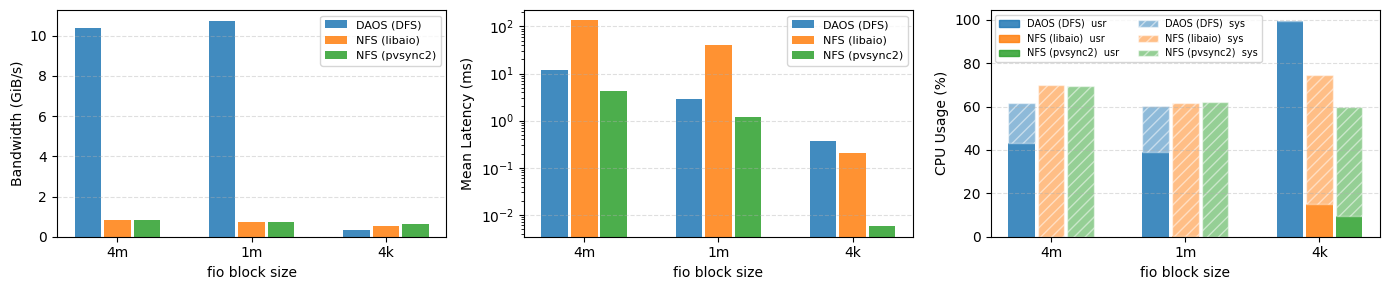

In [28]:
# ── DFS vs NFS: BW / Mean Latency / CPU Usage grouped bar chart ──────────────
bs_order     = ["4m", "1m", "4k"]
engine_order = ["libaio", "pvsync2"]

# ── inline CPU loading (only for engines shown in this chart) ─────────────
_cpu_configs = [
    ("pvsync2", "4k", "pvsync2_nsf_seq_read_bs4k_*.json"),
    ("pvsync2", "1m", "pvsync2_nsf_seq_read_bs1m_*.json"),
    ("pvsync2", "4m", "pvsync2_nsf_seq_read_bs4m_*.json"),
    ("libaio",  "4k", "libaio_nsf_seq_read_bs4k_*.json"),
    ("libaio",  "1m", "libaio_nsf_seq_read_bs1m_*.json"),
    ("libaio",  "4m", "libaio_nsf_seq_read_bs4m_*.json"),
]

def _load_cpu(pattern, z_thresh=2.0):
    files = sorted(RESULTS_DIR.glob(pattern))
    recs = []
    for fpath in files:
        d = json.load(open(fpath))
        j = d["jobs"][0]
        r = j["read"]
        recs.append(dict(bw=r["bw_bytes"] / (1024**3), usr=j["usr_cpu"], sys=j["sys_cpu"]))
    bws = [r["bw"] for r in recs]
    mu  = statistics.mean(bws)
    sd  = statistics.stdev(bws) if len(bws) > 1 else 0
    clean = [r for r in recs if sd == 0 or abs((r["bw"] - mu) / sd) <= z_thresh]
    return (statistics.mean(r["usr"] for r in clean),
            statistics.mean(r["sys"] for r in clean))

_nfs_cpu = {(e, bs): _load_cpu(pat) for e, bs, pat in _cpu_configs}

_dfs_cpu = {}
for bs in ["4k", "1m", "4m"]:
    sub   = daos_df[daos_df.bs == bs]
    clean = sub if bs == "4k" else sub[sub.runtime_s < 3.5]
    _dfs_cpu[bs] = (clean.usr_cpu.mean(), clean.sys_cpu.mean())

# ── chart ─────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

tab10         = plt.cm.get_cmap("tab10")
keys_all      = ["DFS"] + engine_order
display_names = ["DAOS (DFS)"] + [f"NFS ({e})" for e in engine_order]
colors        = {k: tab10(i) for i, k in enumerate(keys_all)}

n_grp   = len(keys_all)
width   = 0.22
x       = np.arange(len(bs_order))
offsets = np.arange(n_grp) * width - (n_grp - 1) * width / 2.0

METRIC_DEFS = [
    ("BW",     "Bandwidth (GiB/s)", False),
    ("lat_ms", "Mean Latency (ms)", True),
    ("cpu",    "CPU Usage (%)",     False),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax, (metric, ylabel, use_log) in zip(axes, METRIC_DEFS):
    for gi, (key, dname) in enumerate(zip(keys_all, display_names)):

        if metric == "BW":
            vals = []
            for bs in bs_order:
                if key == "DFS":
                    vals.append(cmp_df[cmp_df.bs == bs].iloc[0]["DFS_BW"])
                else:
                    row = cmp_df[(cmp_df.bs == bs) & (cmp_df.engine == key)]
                    vals.append(row.iloc[0]["NFS_BW"] if len(row) else np.nan)
            ax.bar(x + offsets[gi], vals, width * 0.9,
                   label=dname, color=colors[key], alpha=0.85)

        elif metric == "lat_ms":
            vals = []
            for bs in bs_order:
                if key == "DFS":
                    vals.append(cmp_df[cmp_df.bs == bs].iloc[0]["DFS_lat_ms"])
                else:
                    row = cmp_df[(cmp_df.bs == bs) & (cmp_df.engine == key)]
                    vals.append(row.iloc[0]["NFS_lat_ms"] if len(row) else np.nan)
            ax.bar(x + offsets[gi], vals, width * 0.9,
                   label=dname, color=colors[key], alpha=0.85)

        else:  # cpu — stacked usr (solid, darker) + sys (hatched, lighter)
            usr_vals, sys_vals = [], []
            for bs in bs_order:
                u, s = _dfs_cpu[bs] if key == "DFS" else _nfs_cpu.get((key, bs), (np.nan, np.nan))
                usr_vals.append(u); sys_vals.append(s)
            ax.bar(x + offsets[gi], usr_vals, width * 0.9,
                   color=colors[key], alpha=0.85)
            ax.bar(x + offsets[gi], sys_vals, width * 0.9,
                   bottom=usr_vals, color=colors[key], alpha=0.5,
                   hatch="///", edgecolor="white", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(bs_order, fontsize=10)
    ax.set_xlabel("fio block size")
    ax.set_ylabel(ylabel)
    if use_log:
        ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    if metric == "cpu":
        # 3 engine legend entries only; usr/sys encoding in title
        usr_patches = [Patch(color=colors[k], alpha=0.85,
                               label=f"{dn}  usr")
                        for k, dn in zip(keys_all, display_names)]
        sys_patches = [Patch(facecolor=colors[k], alpha=0.5, hatch="///",
                               edgecolor="white", label=f"{dn}  sys")
                        for k, dn in zip(keys_all, display_names)]
        ax.legend(handles=usr_patches + sys_patches,
                  fontsize=7, ncol=2, loc="best")
    else:
        ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.savefig("fio-cmp_bw-meanlat-cpu.pdf", dpi=150)
plt.show()


### DFS vs NFS comparison table

DFS values use cached-state runs for bs=1m / 4m; all 10 runs for bs=4k (warming trend, steady-state ~0.34 GiB/s).  
Ratio = DFS / NFS — values > 1 mean DFS wins.

#### bs = 4k

| Engine (NFS) | DFS BW (GiB/s) | NFS BW (GiB/s) | Ratio | DFS IOPS | NFS IOPS | Ratio | DFS lat (ms) | NFS lat (ms) |
|---|---|---|---|---|---|---|---|---|
| pvsync2 | 0.3298 | 0.6102 | 0.54× | 86,462 | 159,973 | 0.54× | 0.3703 | 0.0057 |
| libaio  | 0.3298 | 0.5393 | 0.61× | 86,462 | 141,381 | 0.61× | 0.3703 | 0.2106 |
| psync   | 0.3298 | 0.6314 | 0.52× | 86,462 | 165,512 | 0.52× | 0.3703 | 0.0054 |

#### bs = 1m

| Engine (NFS) | DFS BW (GiB/s) | NFS BW (GiB/s) | Ratio | DFS IOPS | NFS IOPS | Ratio | DFS lat (ms) | NFS lat (ms) |
|---|---|---|---|---|---|---|---|---|
| pvsync2 | 10.745 | 0.7217 | 14.9× | 11,003 | 739 | 14.9× | 2.886 |  1.222 |
| libaio  | 10.745 | 0.7115 | 15.1× | 11,003 | 729 | 15.1× | 2.886 | 39.707 |
| psync   | 10.745 | 0.6787 | 15.8× | 11,003 | 695 | 15.8× | 2.886 |  1.310 |

#### bs = 4m

| Engine (NFS) | DFS BW (GiB/s) | NFS BW (GiB/s) | Ratio | DFS IOPS | NFS IOPS | Ratio | DFS lat (ms) | NFS lat (ms) |
|---|---|---|---|---|---|---|---|---|
| pvsync2 | 10.392 | 0.8317 | 12.5× | 2,660 | 213 | 12.5× | 11.807 |   4.173 |
| libaio  | 10.392 | 0.8241 | 12.6× | 2,660 | 211 | 12.6× | 11.807 | 134.567 |
| psync   | 10.392 | 0.8049 | 12.9× | 2,660 | 206 | 12.9× | 11.807 |   4.348 |

### Key findings

**bs = 4k — NFS wins (~2×)**  
DFS achieves only ~0.33 GiB/s vs NFS ~0.54–0.63 GiB/s, and DFS latency (0.37 ms) is ~70× higher than the best NFS engines (psync/pvsync2 at ~0.005 ms). At small block sizes, the per-I/O overhead of the DAOS client path outweighs the network storage advantage. Note that DFS bs=4k still exhibits a warming curve — steady-state BW is ~0.34 GiB/s.

**bs = 1m — DFS dominates (~15×)**  
Cached DFS delivers ~10.7 GiB/s vs NFS ~0.68–0.72 GiB/s — a **~15× BW advantage**. DFS latency (2.9 ms) is lower than libaio (39.7 ms, due to iodepth=32 queuing) and comparable to psync/pvsync2 (~1.2–1.3 ms, iodepth=1 effectively). Even cold DFS reads (~2.9 GiB/s) would be **~4× above NFS**.

**bs = 4m — DFS dominates (~12.5–12.9×)**  
Cached DFS delivers ~10.4 GiB/s vs NFS ~0.80–0.83 GiB/s — a **~12.5–12.9× advantage** (12.5× vs pvsync2, 12.6× vs libaio, 12.9× vs psync). DFS latency (11.8 ms) is higher than NFS pvsync2 and psync (~4.2–4.3 ms) but far lower than NFS libaio (134.6 ms). Cold DFS (~2.9 GiB/s) is still **~3.5× NFS**.

**Summary:**  
DAOS DFS is the clear winner for large sequential reads (bs ≥ 1m), delivering 12–15× higher bandwidth when the SCM/DRAM cache is warm and 3.5–4× even on cold reads from NVMe. NFS outperforms DFS only at small block sizes (bs=4k), where it delivers ~2× higher BW and dramatically lower per-IO latency (~0.005 ms vs 0.37 ms).

---
## CPU Usage Comparison — DFS vs NFS

Client-side CPU (usr + sys) averaged over clean runs. DFS uses cached-state runs for bs=1m/4m; all 10 runs for bs=4k.

            Source  bs   usr_cpu%   sys_cpu%   total%    BW (GiB/s)
────────────────────────────────────────────────────────────────────
         DFS (all)  4k       99.2        0.3     99.5        0.3298
      DFS (cached)  1m       39.2       21.0     60.2       10.7448
      DFS (cached)  4m       43.3       18.3     61.6       10.3921

        NFS/libaio  4k       15.0       59.6     74.6        0.5393
         NFS/psync  4k        9.5       45.8     55.3        0.6314
       NFS/pvsync2  4k        9.5       50.2     59.7        0.6102

        NFS/libaio  1m        0.1       61.6     61.7        0.7115
         NFS/psync  1m        0.1       61.3     61.4        0.6787
       NFS/pvsync2  1m        0.1       62.2     62.3        0.7217

        NFS/libaio  4m        0.1       69.7     69.8        0.8241
         NFS/psync  4m        0.0       71.5     71.6        0.8049
       NFS/pvsync2  4m        0.0       69.7     69.7        0.8317



/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_12713/3885747344.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10       = plt.cm.get_cmap("tab10")


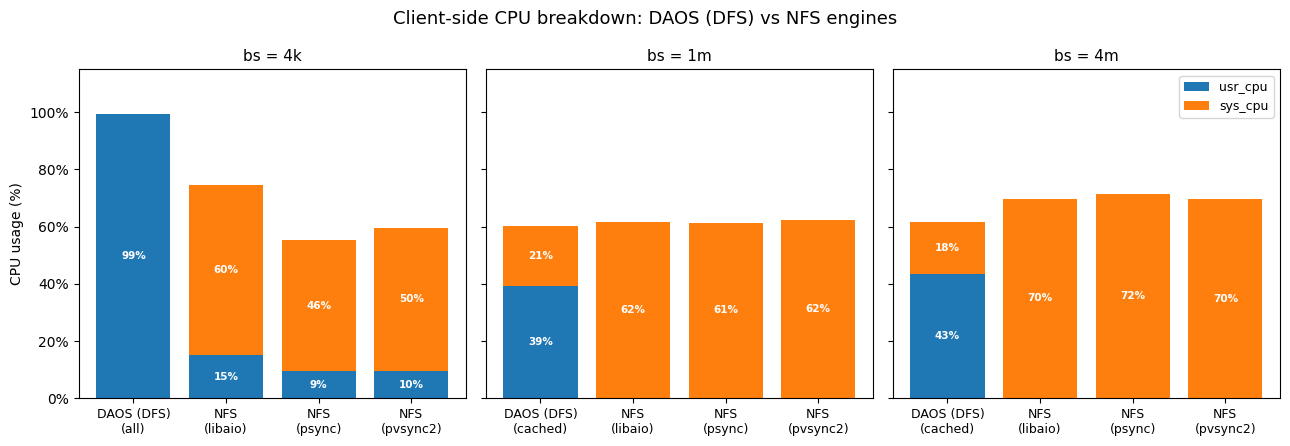

In [16]:
def load_cpu(pattern, z_thresh=2.0):
    """Return (usr_cpu_mean, sys_cpu_mean, bw_mean) after z-score BW filtering."""
    files = sorted(RESULTS_DIR.glob(pattern))
    recs = []
    for fpath in files:
        d = json.load(open(fpath))
        j = d["jobs"][0]
        r = j["read"]
        recs.append(dict(bw=r["bw_bytes"] / (1024**3), usr=j["usr_cpu"], sys=j["sys_cpu"]))
    bws = [r["bw"] for r in recs]
    mu  = statistics.mean(bws)
    sd  = statistics.stdev(bws) if len(bws) > 1 else 0
    clean = [r for r in recs if sd == 0 or abs((r["bw"] - mu) / sd) <= z_thresh]
    return (statistics.mean(r["usr"] for r in clean),
            statistics.mean(r["sys"] for r in clean),
            statistics.mean(r["bw"]  for r in clean))

NFS_CPU_CONFIGS = [
    ("pvsync2", "4k", "pvsync2_nsf_seq_read_bs4k_*.json"),
    ("pvsync2", "1m", "pvsync2_nsf_seq_read_bs1m_*.json"),
    ("pvsync2", "4m", "pvsync2_nsf_seq_read_bs4m_*.json"),
    ("libaio",  "4k", "libaio_nsf_seq_read_bs4k_*.json"),
    ("libaio",  "1m", "libaio_nsf_seq_read_bs1m_*.json"),
    ("libaio",  "4m", "libaio_nsf_seq_read_bs4m_*.json"),
    ("psync",   "4k", "psync_nsf_seq_read_bs4k_*.json"),
    ("psync",   "1m", "psync_nsf_seq_read_bs1m_*.json"),
    ("psync",   "4m", "psync_nsf_seq_read_bs4m_*.json"),
]
NFS_CPU = {(e, bs): load_cpu(pat) for e, bs, pat in NFS_CPU_CONFIGS}

# DFS CPU (cached state for 1m/4m, all runs for 4k)
DFS_CPU = {}
for bs in ["4k", "1m", "4m"]:
    sub = daos_df[daos_df.bs == bs]
    clean = sub if bs == "4k" else sub[sub.runtime_s < 3.5]
    DFS_CPU[bs] = (clean.usr_cpu.mean(), clean.sys_cpu.mean(), clean.bw_GiBs.mean())

# ── summary table ────────────────────────────────────────────────────────────
print(f"{'Source':>18} {'bs':>3}  {'usr_cpu%':>9}  {'sys_cpu%':>9}  {'total%':>7}  {'BW (GiB/s)':>12}")
print("─" * 68)
for bs in ["4k", "1m", "4m"]:
    usr, sys_, bw = DFS_CPU[bs]
    tag = "all" if bs == "4k" else "cached"
    print(f"{'DFS ('+tag+')':>18} {bs:>3}  {usr:>9.1f}  {sys_:>9.1f}  {usr+sys_:>7.1f}  {bw:>12.4f}")
print()
for bs in ["4k", "1m", "4m"]:
    for engine in ["libaio", "psync", "pvsync2"]:
        if (engine, bs) not in NFS_CPU:
            continue
        usr, sys_, bw = NFS_CPU[(engine, bs)]
        print(f"{'NFS/'+engine:>18} {bs:>3}  {usr:>9.1f}  {sys_:>9.1f}  {usr+sys_:>7.1f}  {bw:>12.4f}")
    print()

# ── stacked bar chart ────────────────────────────────────────────────────────
tab10       = plt.cm.get_cmap("tab10")
engines_nfs = ["libaio", "psync", "pvsync2"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
fig.suptitle("Client-side CPU breakdown: DAOS (DFS) vs NFS engines", fontsize=13)

for ax, bs in zip(axes, ["4k", "1m", "4m"]):
    labels, usr_vals, sys_vals = [], [], []

    # DFS first
    u, s, _ = DFS_CPU[bs]
    tag = "all" if bs == "4k" else "cached"
    labels.append(f"DAOS (DFS)\n({tag})")
    usr_vals.append(u); sys_vals.append(s)

    # NFS engines
    for eng in engines_nfs:
        u, s, _ = NFS_CPU[(eng, bs)]
        labels.append(f"NFS\n({eng})")
        usr_vals.append(u); sys_vals.append(s)

    x = range(len(labels))
    ax.bar(x, usr_vals, label="usr_cpu", color=tab10(0))
    ax.bar(x, sys_vals, bottom=usr_vals, label="sys_cpu", color=tab10(1))

    # value labels
    for xi, (u, s) in enumerate(zip(usr_vals, sys_vals)):
        if u >= 3:
            ax.text(xi, u / 2, f"{u:.0f}%", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
        if s >= 3:
            ax.text(xi, u + s / 2, f"{s:.0f}%", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

    ax.set_title(f"bs = {bs}", fontsize=11)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    if ax == axes[0]:
        ax.set_ylabel("CPU usage (%)")

axes[-1].legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


### CPU findings

| Source | bs | usr_cpu | sys_cpu | total | BW (GiB/s) |
|---|---|---|---|---|---|
| DFS (all)    | 4k | 99.2% |  0.3% |  99.5% | 0.330 |
| DFS (cached) | 1m | 39.2% | 21.0% |  60.2% | 10.745 |
| DFS (cached) | 4m | 43.3% | 18.3% |  61.6% | 10.392 |
| NFS/pvsync2  | 4k |  9.5% | 50.2% |  59.7% | 0.610 |
| NFS/pvsync2  | 1m |  0.1% | 62.2% |  62.3% | 0.722 |
| NFS/pvsync2  | 4m |  0.0% | 69.7% |  69.7% | 0.832 |
| NFS/libaio   | 4k | 15.0% | 59.6% |  74.6% | 0.539 |
| NFS/libaio   | 1m |  0.1% | 61.6% |  61.7% | 0.712 |
| NFS/libaio   | 4m |  0.1% | 69.7% |  69.8% | 0.824 |
| NFS/psync    | 4k |  9.5% | 45.8% |  55.3% | 0.631 |
| NFS/psync    | 1m |  0.1% | 61.4% |  61.5% | 0.679 |
| NFS/psync    | 4m |  0.0% | 71.5% |  71.5% | 0.805 |

**DFS is user-space dominated; NFS is kernel-space dominated.** This reflects a fundamental architectural split:
- **DFS**: the DAOS client library (`libdaos`) handles all I/O in user space via RDMA — no syscalls on the data path. At bs=4k the client is CPU-bound at ~99% usr_cpu, which explains why DFS underperforms NFS at that block size. For large bs (1m/4m) with cached data, usr_cpu drops to ~39–43% and sys_cpu rises to ~18–21% as RDMA completions and memory copies generate kernel activity.
- **NFS**: essentially zero usr_cpu regardless of block size. All I/O passes through the kernel NFS/NVMe-oF stack — sys_cpu is 46–72% and scales with bandwidth rather than block size.

**bs=4k bottleneck:** DFS burns ~99% of a single CPU core doing user-space processing for small-block I/O, capping throughput at ~0.33 GiB/s. NFS routes the same I/O through the kernel at only ~50–60% sys_cpu and achieves ~0.54–0.63 GiB/s. Improving DFS small-block performance likely requires either batching or reducing per-I/O user-space overhead.

**Cached large-bs:** DFS total CPU (~60–62%) is comparable to NFS (~62–72%) despite delivering 12–15× more bandwidth — meaning DFS is dramatically more CPU-efficient per GiB transferred at large block sizes.

---
## I/O Queue Depth Analysis

fio reports three queue depth histograms and one depth setting per job:

| Field | What it measures |
|---|---|
| `iodepth_level` | % of time the queue had exactly N I/Os in flight simultaneously |
| `iodepth_submit` | % of submission calls that submitted 1–N I/Os at once |
| `iodepth_complete` | % of completion calls that reaped 1–N I/Os at once |
| `latency_depth` | The configured `iodepth` value (32 in all these runs) |

### Bucket label encoding

**Bucket labels are upper bounds of ranges**, not exact counts:

| Bucket key | Actual range of IOs per call |
|---|---|
| `"0"` | 0 IOs |
| `"4"` | 1–4 IOs |
| `"8"` | 5–8 IOs |
| `"16"` | 9–16 IOs |
| `"32"` | 17–32 IOs |
| `">=64"` | 33+ IOs |

So **"100% at '4'"** means every call processed somewhere between 1 and 4 IOs — most often exactly 1.

### Why async engines show `iodepth_submit/complete = "4"` despite `iodepth=32`

It seems paradoxical that libaio and DFS keep 32 IOs in-flight (`iodepth_level ~100% at 32`) yet submit/complete only 1–4 at a time. The mechanism is a **steady-state trickle**:

1. FIO fills the queue to 32 at startup (an initial burst).
2. Once full, each `io_getevents()` call reaps however many completions have arrived — typically **1–4 at a time** because completions stagger as they return from the network/storage.
3. FIO immediately re-submits **exactly that many** new IOs to top the queue back to 32.

The queue depth stays pinned at 32, but the drip rate of individual `io_submit()` / `io_getevents()` calls is 1–4, so both fall in bucket `"4"`.

### What the distributions reveal per engine type

| Engine | iodepth_level | iodepth_submit | iodepth_complete | Interpretation |
|---|---|---|---|---|
| **libaio** | ~100% at 32 | 100% at "4" (1–4) | ~100% at "4", trace at 32 | Full async: 32 IOs in-flight, refilled 1–4 at a time as completions trickle in |
| **DFS** | ~100% at 32 | 100% at "4" (1–4) | ~100% at "4", trace at 32 | Same async behaviour as libaio — DAOS client runs its own async I/O path |
| **pvsync2** | 100% at 1 | 100% at "4" (1) | 100% at "4" (1) | Fully synchronous: 1 I/O in-flight at a time, submit–wait–complete per I/O |
| **psync** | 100% at 1 | 100% at "4" (1) | 100% at "4" (1) | Same as pvsync2 — effective iodepth = 1 despite `iodepth=32` config |

> The `iodepth=32` setting in the fio job file is **not utilized** by synchronous engines (pvsync2, psync).  
> libaio and DFS actually exploit it, keeping 32 I/Os in-flight at all times.

In [17]:
import statistics

IODEPTH_CONFIGS = [
    ("DFS",     "4k", "dfs_seq_read_bs4k_*.json"),
    ("DFS",     "1m", "dfs_seq_read_bs1m_*.json"),
    ("DFS",     "4m", "dfs_seq_read_bs4m_*.json"),
    ("pvsync2", "4k", "pvsync2_nsf_seq_read_bs4k_*.json"),
    ("pvsync2", "1m", "pvsync2_nsf_seq_read_bs1m_*.json"),
    ("pvsync2", "4m", "pvsync2_nsf_seq_read_bs4m_*.json"),
    ("libaio",  "4k", "libaio_nsf_seq_read_bs4k_*.json"),
    ("libaio",  "1m", "libaio_nsf_seq_read_bs1m_*.json"),
    ("libaio",  "4m", "libaio_nsf_seq_read_bs4m_*.json"),
    ("psync",   "4k", "psync_nsf_seq_read_bs4k_*.json"),
    ("psync",   "1m", "psync_nsf_seq_read_bs1m_*.json"),
    ("psync",   "4m", "psync_nsf_seq_read_bs4m_*.json"),
]

LEVEL_KEYS    = ["1", "2", "4", "8", "16", "32", ">=64"]
SUBMIT_KEYS   = ["0", "4", "8", "16", "32", "64", ">=64"]

rows = []
for engine, bs, pat in IODEPTH_CONFIGS:
    files = sorted(RESULTS_DIR.glob(pat))
    if not files:
        continue
    levels, submits, completes = {}, {}, {}
    for fpath in files:
        d = json.load(open(fpath))
        j = d["jobs"][0]
        for k, v in j["iodepth_level"].items():
            levels.setdefault(k, []).append(v)
        for k, v in j["iodepth_submit"].items():
            submits.setdefault(k, []).append(v)
        for k, v in j["iodepth_complete"].items():
            completes.setdefault(k, []).append(v)
    rows.append((engine, bs, len(files), levels, submits, completes))

# ── iodepth_level heatmap (% time at each depth) ──────────────────────────
print("iodepth_level  — % of time queue held exactly N IOs in-flight")
hdr = f"{'Engine':>8} {'bs':>3}  {'n':>3}  " + "  ".join(f"{k:>6}" for k in LEVEL_KEYS)
print(hdr)
print("─" * len(hdr))
for engine, bs, n, levels, submits, completes in rows:
    row = f"{engine:>8} {bs:>3}  {n:>3}  "
    for k in LEVEL_KEYS:
        if k in levels:
            m = statistics.mean(levels[k])
            row += f"  {m:>6.1f}"
        else:
            row += f"  {'—':>6}"
    print(row)

print()
print("iodepth_submit — % of submission calls that sent 1..N IOs at once")
hdr2 = f"{'Engine':>8} {'bs':>3}  {'n':>3}  " + "  ".join(f"{k:>6}" for k in SUBMIT_KEYS)
print(hdr2)
print("─" * len(hdr2))
for engine, bs, n, levels, submits, completes in rows:
    row = f"{engine:>8} {bs:>3}  {n:>3}  "
    for k in SUBMIT_KEYS:
        if k in submits:
            m = statistics.mean(submits[k])
            row += f"  {m:>6.1f}" if m > 0.001 else f"  {'0.0':>6}"
        else:
            row += f"  {'—':>6}"
    print(row)


iodepth_level  — % of time queue held exactly N IOs in-flight
  Engine  bs    n       1       2       4       8      16      32    >=64
─────────────────────────────────────────────────────────────────────────
     DFS  4k   10       0.1     0.1     0.1     0.1     0.1   100.0     0.0
     DFS  1m   10       0.1     0.1     0.1     0.1     0.1    99.9     0.0
     DFS  4m   10       0.1     0.1     0.1     0.1     0.2    99.6     0.0
 pvsync2  4k   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
 pvsync2  1m   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
 pvsync2  4m   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
  libaio  4k   10       0.1     0.1     0.1     0.1     0.1   100.0     0.0
  libaio  1m   10       0.1     0.1     0.1     0.1     0.1    99.9     0.0
  libaio  4m   13       0.1     0.1     0.1     0.1     0.2    99.6     0.0
   psync  4k   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
   psync  1m   10     100.0   